In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhruvbchokshi/wine-dataset-2c/wine_dataset.csv


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/dhruvbchokshi/wine-dataset-2c/wine_dataset.csv')

# See first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [14]:
# Basic info
df.info()

# Statistical summary
df.describe()

# Column names
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

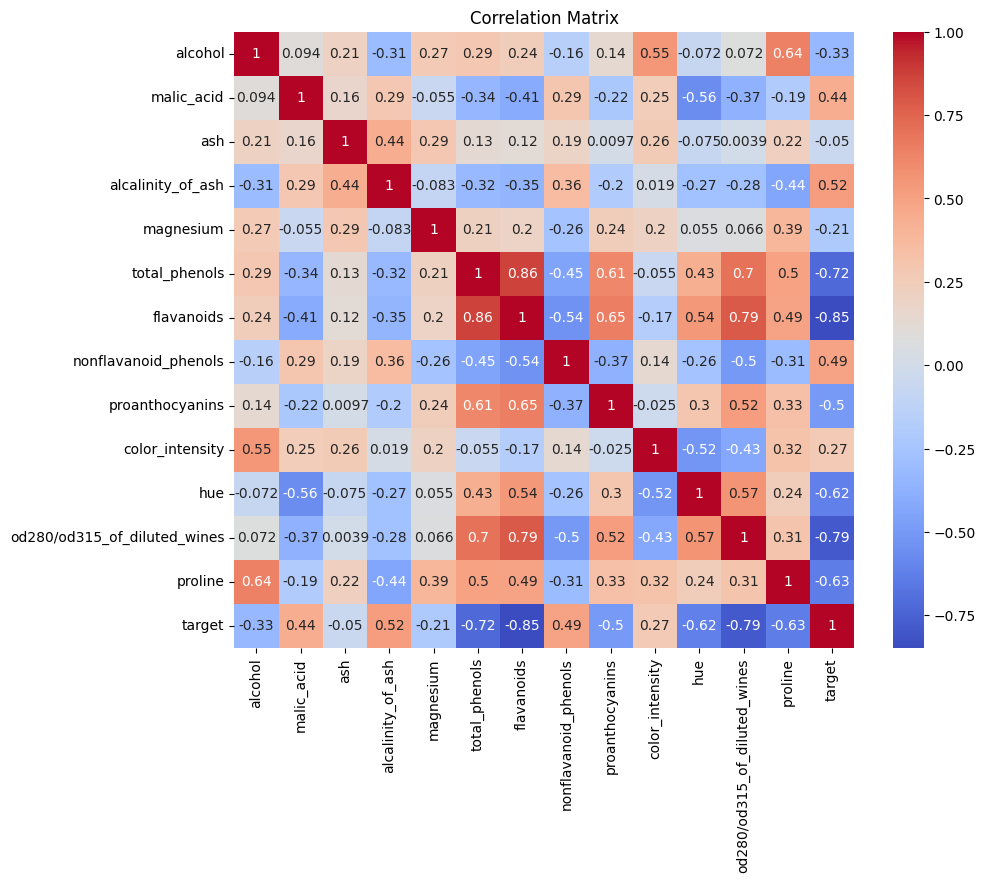

In [15]:
# Correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [16]:
features = ['flavanoids', 'proline', 'alcalinity_of_ash']
target = 'target'

## Feature Selection Justification

For this task, we were required to choose any 3 features to train a Linear Regression model. However, instead of selecting features randomly, we used the **correlation matrix** to make an informed decision.

### 1. Correlation with Target
We first analyzed how each feature is related to the target variable (`target`):
- `flavanoids` showed a very strong negative correlation (~ -0.85)
- `proline` showed a moderate negative correlation (~ -0.63)
- `alcalinity_of_ash` showed a moderate positive correlation (~ 0.52)

These features are good predictors because they have a significant relationship with the target.

### 2. Avoiding Multicollinearity
Some features like:
- `flavanoids`
- `total_phenols`
- `od280/od315_of_diluted_wines`

are highly correlated with each other (correlation > 0.7). This means they carry **redundant information**.

Using such features together can lead to **multicollinearity**, which:
- Makes the model unstable
- Reduces interpretability
- Affects coefficient estimation

### 3. Final Feature Selection
We selected:
- `flavanoids` (strong predictor)
- `proline` (good predictor, less redundancy)
- `alcalinity_of_ash` (adds diversity)

### Conclusion
The selected features provide a balance between:
- Strong predictive power
- Low redundancy between features

This ensures a more reliable and interpretable Linear Regression model.

In [17]:
X = df[['flavanoids', 'proline', 'alcalinity_of_ash']]
y = df['target']

In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print(X_train.shape, X_test.shape)

(142, 3) (36, 3)


In [19]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [20]:
# Predict on test data
y_pred = model.predict(X_test)

In [21]:
# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.10886869295580183
R2 Score: 0.8133679549329111


## Model Results and Conclusion

A Linear Regression model was trained using three selected features:
- flavanoids
- proline
- alcalinity_of_ash

### Model Performance
- Mean Squared Error (MSE): 0.1089
- R² Score: 0.8134

### Interpretation
The R² score of 0.81 indicates that the model explains approximately 81% of the variance in the target variable. This suggests a strong relationship between the selected features and the target.

### Key Observations
- `flavanoids` was the most influential feature due to its strong correlation with the target.
- Feature selection based on correlation helped improve model performance.
- Avoiding highly correlated features (multicollinearity) made the model more stable and reliable.

### Conclusion
Even though the dataset is primarily meant for classification, Linear Regression was able to model the relationships effectively. Proper feature selection played a crucial role in achieving good performance.